In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots appear inside the notebook
%matplotlib inline

In [2]:
import os

print("Files in current folder:")
print(os.listdir())

print("\nFiles in parent folder:")
print(os.listdir(".."))

Files in current folder:
['.ipynb_checkpoints', 'Level1_Task1.ipynb', 'Level1_Task2.ipynb', 'Level1–Task3.ipynb', 'Level1–Task4.ipynb']

Files in parent folder:
['.git', '.ipynb_checkpoints', 'Dataset.csv', 'images', 'notebooks']


In [3]:
df = pd.read_csv("../Dataset.csv")

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.shape

(9551, 21)

In [6]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [8]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

# Level 1 - Task 1: Top Cuisines

## Objective
The objective of this task is to analyze the cuisine information available in the restaurant dataset.

### The task includes:
- Finding the top 3 most common cuisines.
- Calculating the percentage of restaurants serving each of the top cuisines.
- Visualizing the results using a bar chart.

### Libraries Used
- Pandas
- Matplotlib
- Seaborn

## Step 1: Check Missing Values in the Cuisines Column

Before performing any analysis, it is important to identify missing values.

Missing cuisine information can affect the accuracy of the analysis.

In [11]:
# Check missing values in Cuisines column
df["Cuisines"].isnull().sum()

9

## Step 2: Remove Missing Values

The dataset contains only a few missing values (9 records).

These rows will be removed to ensure accurate analysis.

In [13]:
# Remove rows where Cuisines is missing
df = df.dropna(subset=["Cuisines"])

# Verify
df["Cuisines"].isnull().sum()

0

## Step 3: Split Multiple Cuisines

Many restaurants serve more than one cuisine.

For example,

French, Japanese, Desserts

should be counted as

- French
- Japanese
- Desserts

This provides a more accurate cuisine frequency.

In [15]:
# Split multiple cuisines into individual cuisines
all_cuisines = df["Cuisines"].str.split(", ").explode()

# Display first few cuisines
all_cuisines.head()

0      French
0    Japanese
0    Desserts
1    Japanese
2     Seafood
Name: Cuisines, dtype: object

## Step 4: Count the Frequency of Each Cuisine

Count how many restaurants serve each cuisine.

In [17]:
# Count cuisine frequencies
cuisine_counts = all_cuisines.value_counts()

# Display top 10 cuisines
cuisine_counts.head(10)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

## Step 5: Identify the Top 3 Cuisines

The top three cuisines are selected based on the highest frequency.

In [19]:
top3 = cuisine_counts.head(3)

top3

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

## Step 6: Calculate the Percentage of Restaurants

Percentage is calculated using the formula:

Percentage = (Cuisine Count / Total Restaurants) × 100

In [21]:
total_restaurants = len(df)

percentage = (top3 / total_restaurants) * 100

percentage

Cuisines
North Indian    41.500734
Chinese         28.662754
Fast Food       20.813247
Name: count, dtype: float64

## Step 7: Create a Summary Table

A summary table is created showing the cuisine count and percentage.

In [23]:
summary = pd.DataFrame({
    "Cuisine": top3.index,
    "Restaurant Count": top3.values,
    "Percentage": percentage.values.round(2)
})

summary

,Cuisine,Restaurant Count,Percentage
0,North Indian,3960,41.50
1,Chinese,2735,28.66
2,Fast Food,1986,20.81


## Step 8: Visualize the Top 3 Cuisines

A bar chart is created to compare the most common cuisines.

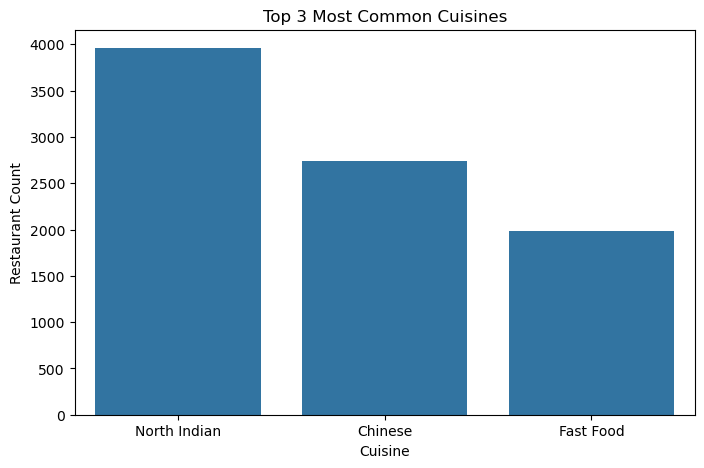

In [25]:
import os

os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x="Cuisine",
    y="Restaurant Count"
)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Restaurant Count")

plt.savefig(
    "../images/top3_cuisines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

### Key Findings

- The dataset contains restaurants serving multiple cuisines.
- The top three cuisines are the most frequently offered among all restaurants.
- These cuisines represent the dominant food preferences in the dataset.
- The bar chart clearly shows the popularity of each cuisine.

This analysis helps understand customer preferences and restaurant trends.